In [ ]:
# ============================================================
# INSTALL LIBRARIES
# ============================================================
!pip install albumentations opencv-python -q

import os
import cv2
import random
import albumentations as A
import numpy as np

# ============================================================
# DATASET PATHS
# ============================================================

image_dir = "/content/drive/MyDrive/mes_project/MES_DATASET"
label_dir = "/content/drive/MyDrive/mes_project/kitti_label"

out_image_dir = "/content/drive/MyDrive/mes_project/MES_DATASET_aug"
out_label_dir = "/content/drive/MyDrive/mes_project/kitti_label_aug"

os.makedirs(out_image_dir, exist_ok=True)
os.makedirs(out_label_dir, exist_ok=True)

# ============================================================
# SCENE + POINT LEVEL AUGMENTATIONS
# ============================================================

transform = A.Compose(
[
    # ---------- SCENE LEVEL ----------
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=15, p=0.4),

    # safer replacement for ShiftScaleRotate
    A.Affine(
        scale=(0.9,1.1),
        translate_percent=(-0.05,0.05),
        rotate=(-10,10),
        p=0.5
    ),

    # ---------- POINT LEVEL ----------
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.3),
    A.MotionBlur(p=0.2),
    A.RandomShadow(p=0.3),

],
bbox_params=A.BboxParams(format="yolo", label_fields=["class_labels"])
)

# ============================================================
# OBJECT LEVEL AUGMENTATION (SAFE COPY PASTE)
# ============================================================

def copy_paste_object(image, bbox):

    h, w, _ = image.shape
    x, y, bw, bh = bbox

    # convert YOLO bbox → pixel coords
    x1 = int((x - bw/2) * w)
    y1 = int((y - bh/2) * h)
    x2 = int((x + bw/2) * w)
    y2 = int((y + bh/2) * h)

    x1 = max(0,x1)
    y1 = max(0,y1)
    x2 = min(w,x2)
    y2 = min(h,y2)

    obj = image[y1:y2, x1:x2]

    if obj.size == 0:
        return image

    obj_h, obj_w = obj.shape[:2]

    # choose safe paste position
    nx = random.randint(0, max(0, w - obj_w))
    ny = random.randint(0, max(0, h - obj_h))

    # clip region safely
    paste_region = image[ny:ny+obj_h, nx:nx+obj_w]

    min_h = min(paste_region.shape[0], obj_h)
    min_w = min(paste_region.shape[1], obj_w)

    image[ny:ny+min_h, nx:nx+min_w] = obj[0:min_h, 0:min_w]

    return image

# ============================================================
# AUGMENT DATASET
# ============================================================

augmentations_per_image = 3

for img_name in os.listdir(image_dir):

    if not img_name.endswith((".jpg",".png",".jpeg")):
        continue

    img_path = os.path.join(image_dir, img_name)
    label_path = os.path.join(label_dir, img_name.split(".")[0] + ".txt")

    image = cv2.imread(img_path)

    bboxes = []
    labels = []

    with open(label_path) as f:
        for line in f.readlines():
            cls, x, y, w, h = map(float, line.split())
            bboxes.append([x,y,w,h])
            labels.append(int(cls))

    for i in range(augmentations_per_image):

        aug = transform(image=image, bboxes=bboxes, class_labels=labels)

        aug_img = aug["image"]
        aug_boxes = aug["bboxes"]
        aug_labels = aug["class_labels"]

        # ---------- OBJECT LEVEL ----------
        if len(aug_boxes) > 0 and random.random() < 0.5:

            idx = random.randint(0, len(aug_boxes)-1)
            aug_img = copy_paste_object(aug_img, aug_boxes[idx])

        new_img = f"aug_{i}_{img_name}"
        new_lbl = f"aug_{i}_{img_name.split('.')[0]}.txt"

        cv2.imwrite(os.path.join(out_image_dir,new_img), aug_img)

        with open(os.path.join(out_label_dir,new_lbl),"w") as f:
            for cls,box in zip(aug_labels,aug_boxes):
                x,y,w,h = box
                f.write(f"{cls} {x} {y} {w} {h}\n")

print("Augmentation completed successfully.")

Augmentation completed successfully.


kal raat ko augmentation kiya tha, toh upar vala jo code hai, woh kal raat ko augmentation ka hai


TOTAL AUGMENTED IMAGES: 3354
EMPTY LABEL FILES: 28

TOTAL OBJECTS: 20061

OBJECT COUNTS
truck : 1260
car : 2756
pedestrian : 8417
motorcycle : 2893
bicycle : 654
bus : 894
auto : 1698
tractor : 1489

IMAGE COUNTS
truck : 1002
car : 1491
motorcycle : 1550
pedestrian : 2516
bicycle : 460
bus : 711
auto : 964
tractor : 1036

ONLY-CLASS IMAGES
truck : 95
bicycle : 6
car : 93
auto : 39
tractor : 125
bus : 62
motorcycle : 30
pedestrian : 35

MULTI-CLASS IMAGES: 2841

AVERAGE OBJECTS PER IMAGE
5.981216457960644

TOP CLASS COMBINATIONS
['motorcycle', 'pedestrian'] : 231
['car', 'motorcycle', 'pedestrian'] : 169
['car', 'motorcycle', 'pedestrian', 'truck'] : 137
['tractor'] : 125
['motorcycle', 'pedestrian', 'truck'] : 124
['truck'] : 95
['car'] : 93
['pedestrian', 'truck'] : 92
['motorcycle', 'pedestrian', 'tractor'] : 92
['car', 'pedestrian'] : 86


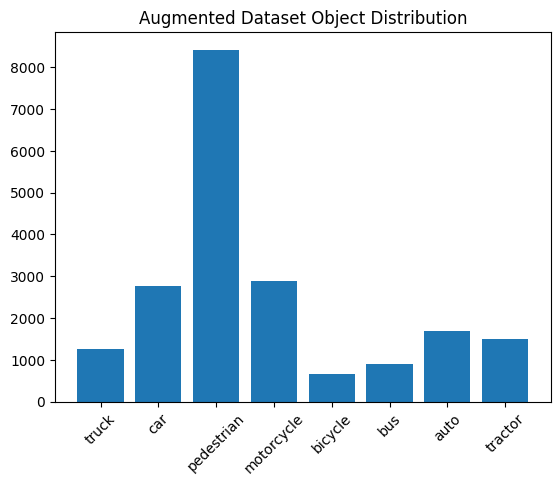

In [2]:
# ============================================================
# ANALYZE AUGMENTED DATASET (ROBUST VERSION)
# ============================================================

import os
from collections import Counter
import matplotlib.pyplot as plt

label_dir = "/content/drive/MyDrive/mes_project/kitti_label_aug"

classes = {
0:"car",
1:"motorcycle",
2:"bicycle",
3:"pedestrian",
4:"auto",
5:"bus",
6:"truck",
7:"tractor"
}

object_counts = Counter()
image_counts = Counter()
only_class_images = Counter()
combination_counts = Counter()

total_images = 0
multi_class_images = 0
total_objects = 0
empty_labels = 0

for file in os.listdir(label_dir):

    if not file.endswith(".txt"):
        continue

    total_images += 1
    path = os.path.join(label_dir,file)

    classes_in_image = []

    with open(path) as f:
        lines = f.readlines()

    if len(lines) == 0:
        empty_labels += 1
        continue

    for line in lines:

        parts = line.split()

        if len(parts) < 5:
            continue

        cls = int(float(parts[0]))   # <-- FIX HERE

        object_counts[cls] += 1
        classes_in_image.append(cls)
        total_objects += 1

    unique_classes = set(classes_in_image)

    for c in unique_classes:
        image_counts[c] += 1

    if len(unique_classes) == 1:
        only_class_images[list(unique_classes)[0]] += 1

    if len(unique_classes) > 1:
        multi_class_images += 1

    combination_counts[tuple(sorted(unique_classes))] += 1


# ============================================================
# PRINT STATISTICS
# ============================================================

print("\nTOTAL AUGMENTED IMAGES:", total_images)
print("EMPTY LABEL FILES:", empty_labels)

print("\nTOTAL OBJECTS:", total_objects)

print("\nOBJECT COUNTS")
for k,v in object_counts.items():
    print(classes[k],":",v)

print("\nIMAGE COUNTS")
for k,v in image_counts.items():
    print(classes[k],":",v)

print("\nONLY-CLASS IMAGES")
for k,v in only_class_images.items():
    print(classes[k],":",v)

print("\nMULTI-CLASS IMAGES:", multi_class_images)

print("\nAVERAGE OBJECTS PER IMAGE")
print(total_objects/total_images)


# ============================================================
# CLASS COMBINATIONS
# ============================================================

print("\nTOP CLASS COMBINATIONS")

for combo,count in combination_counts.most_common(10):

    names=[classes[c] for c in combo]
    print(names,":",count)


# ============================================================
# OBJECT DISTRIBUTION GRAPH
# ============================================================

names=[classes[c] for c in object_counts.keys()]
counts=list(object_counts.values())

plt.figure()
plt.bar(names,counts)
plt.xticks(rotation=45)
plt.title("Augmented Dataset Object Distribution")
plt.show()

yeh upar wala analysis bhi kal raat ke augmentation ke upar hee hai

In [4]:
pip install ultralytics opencv-python matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00


Streaming output truncated to the last 5000 lines.
Speed: 3.4ms preprocess, 44.8ms inference, 1.6ms postprocess per image at shape (1, 3, 640, 480)

0: 640x480 (no detections), 45.0ms
Speed: 3.9ms preprocess, 45.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 480)

0: 384x640 4 persons, 2 motorcycles, 1 dining table, 38.6ms
Speed: 3.3ms preprocess, 38.6ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 2 motorcycles, 37.5ms
Speed: 3.6ms preprocess, 37.5ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 1 person, 1 car, 1 motorcycle, 32.0ms
Speed: 3.8ms preprocess, 32.0ms inference, 1.9ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 3 persons, 3 motorcycles, 1 truck, 1 dining table, 32.2ms
Speed: 3.9ms preprocess, 32.2ms inference, 2.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 2 trucks, 33.2ms
Speed: 5.1ms preprocess, 33.2ms inference, 1.5ms postprocess per image at sh

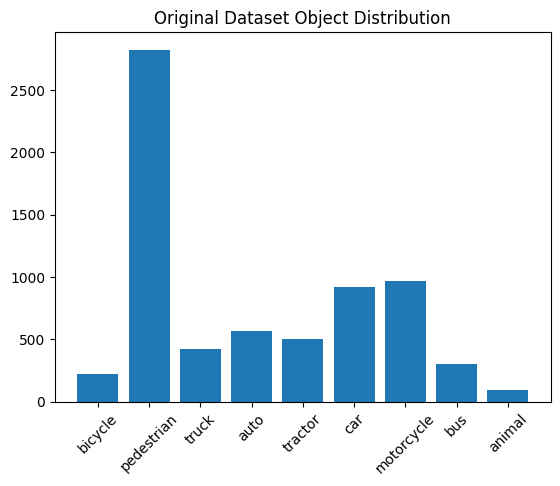


DATASET ANALYSIS: Augmented Dataset

TOTAL IMAGES: 3354
TOTAL OBJECTS: 17479

OBJECT COUNTS
truck : 1114
tractor : 1314
car : 2603
motorcycle : 2245
pedestrian : 6900
auto : 1708
bicycle : 526
bus : 876
animal : 193

IMAGE COUNTS
truck : 845
tractor : 898
car : 1421
motorcycle : 1168
pedestrian : 2121
auto : 922
bicycle : 362
bus : 664
animal : 156

MULTI CLASS IMAGES: 2483

AVERAGE OBJECTS PER IMAGE
5.2113893858079905

TOP CLASS COMBINATIONS
['motorcycle', 'pedestrian'] : 184
['car'] : 177
[] : 162
['tractor'] : 151
['truck'] : 115
['car', 'motorcycle', 'pedestrian'] : 103
['car', 'pedestrian'] : 99
['bus'] : 98
['motorcycle', 'pedestrian', 'truck'] : 82
['car', 'motorcycle', 'pedestrian', 'truck'] : 79


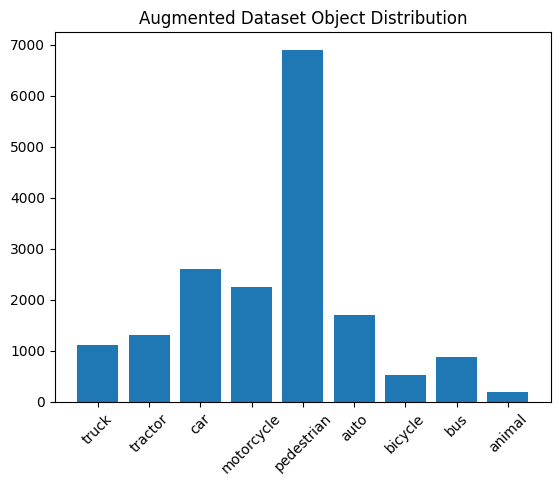


Pipeline completed successfully.


In [5]:
import os
import cv2
from ultralytics import YOLO
from collections import Counter
import matplotlib.pyplot as plt

# ============================================================
# LOAD MODEL
# ============================================================

model = YOLO("yolov8x.pt")

# ============================================================
# DATASET PATHS
# ============================================================

orig_images = "/content/drive/MyDrive/mes_project/MES_DATASET"
orig_labels = "/content/drive/MyDrive/mes_project/original_labels"

aug_images = "/content/drive/MyDrive/mes_project/MES_DATASET_aug"
aug_labels = "/content/drive/MyDrive/mes_project/augmented_labels"

os.makedirs(orig_labels, exist_ok=True)
os.makedirs(aug_labels, exist_ok=True)

# ============================================================
# CLASS DEFINITIONS
# ============================================================

classes = {
0:"car",
1:"motorcycle",
2:"bicycle",
3:"pedestrian",
4:"auto",
5:"bus",
6:"truck",
7:"tractor",
8:"animal",
9:"unknown"
}

# COCO -> dataset mapping
vehicle_map = {
0:3,
1:2,
2:0,
3:1,
5:5,
7:6
}

animal_classes = [15,16,17,18,19,20,21,22,23,24]

# ============================================================
# LABEL GENERATION FUNCTION
# ============================================================

def generate_labels(image_folder, label_folder):

    for img_name in os.listdir(image_folder):

        if not img_name.endswith((".jpg",".png",".jpeg")):
            continue

        img_path = os.path.join(image_folder,img_name)
        img = cv2.imread(img_path)

        results = model(img)[0]

        label_path = os.path.join(label_folder,img_name.split(".")[0]+".txt")

        with open(label_path,"w") as f:

            for box in results.boxes:

                coco_cls = int(box.cls[0])
                conf = float(box.conf[0])

                if conf < 0.35:
                    continue

                x,y,w,h = box.xywhn[0]

                if coco_cls in vehicle_map:

                    cls = vehicle_map[coco_cls]

                    aspect = float(w)/float(h)

                    if cls == 0 and aspect < 0.8:
                        cls = 4

                    if cls == 6 and aspect < 0.9:
                        cls = 7

                elif coco_cls in animal_classes:

                    cls = 8

                else:
                    continue

                f.write(f"{cls} {x} {y} {w} {h}\n")

# ============================================================
# DATASET ANALYSIS FUNCTION
# ============================================================

def analyze_dataset(label_dir, title):

    object_counts = Counter()
    image_counts = Counter()
    combination_counts = Counter()

    total_images = 0
    total_objects = 0
    multi_class_images = 0

    for file in os.listdir(label_dir):

        if not file.endswith(".txt"):
            continue

        total_images += 1

        path = os.path.join(label_dir,file)

        classes_in_image = []

        with open(path) as f:
            lines = f.readlines()

        for line in lines:

            parts = line.split()

            if len(parts) < 5:
                continue

            cls = int(float(parts[0]))

            object_counts[cls]+=1
            classes_in_image.append(cls)
            total_objects += 1

        unique = set(classes_in_image)

        for c in unique:
            image_counts[c]+=1

        if len(unique) > 1:
            multi_class_images += 1

        combination_counts[tuple(sorted(unique))]+=1

    print("\n==============================")
    print("DATASET ANALYSIS:",title)
    print("==============================")

    print("\nTOTAL IMAGES:",total_images)
    print("TOTAL OBJECTS:",total_objects)

    print("\nOBJECT COUNTS")
    for k,v in object_counts.items():
        print(classes[k],":",v)

    print("\nIMAGE COUNTS")
    for k,v in image_counts.items():
        print(classes[k],":",v)

    print("\nMULTI CLASS IMAGES:",multi_class_images)

    print("\nAVERAGE OBJECTS PER IMAGE")
    if total_images > 0:
        print(total_objects/total_images)

    print("\nTOP CLASS COMBINATIONS")

    for combo,count in combination_counts.most_common(10):

        names=[classes[c] for c in combo]
        print(names,":",count)

    # distribution graph
    names=[classes[c] for c in object_counts.keys()]
    counts=list(object_counts.values())

    plt.figure()
    plt.bar(names,counts)
    plt.xticks(rotation=45)
    plt.title(title + " Object Distribution")
    plt.show()


# ============================================================
# RUN LABEL GENERATION
# ============================================================

print("Generating labels for ORIGINAL dataset...")
generate_labels(orig_images, orig_labels)

print("Generating labels for AUGMENTED dataset...")
generate_labels(aug_images, aug_labels)

# ============================================================
# RUN ANALYSIS
# ============================================================

analyze_dataset(orig_labels,"Original Dataset")

analyze_dataset(aug_labels,"Augmented Dataset")

print("\nPipeline completed successfully.")

abb yeh upar wala code naye labels ke liye hai kyunki usne bola tha ki animals bhi detect karne hai, toh maine saare labels: original wala aur augmented wala ida diya aur images ka naya label phirse banaya jisme animals bhi included hai, toh abhi yeh analysis bhi hai